# Quantifying the quality of a Fitting

Importing packages

In [4]:
from myutils.g_values.best_fit import TheoMatchExpe
from myutils.plotters import StandardPlotter
from scipy.stats import pearsonr
import numpy as np

## Best fitting of a function as a linear combination of another

We take two functions, f(x) and g(x) = f(x + 8). We try to automatically find
a coeficient c, such that c * g(x) minimizes the error respect to f(x)

<Axes: xlabel='Field [T]', ylabel='Intensity [a.u]'>

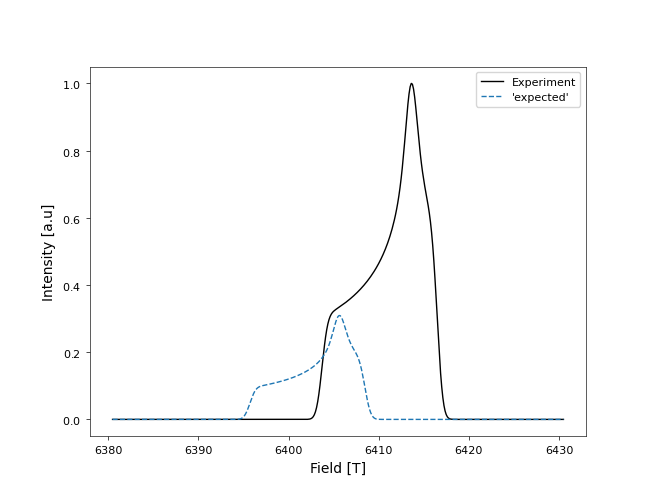

In [5]:
tme = TheoMatchExpe(['shifted-spectrum2.dat'],
                    experiment_file='spectrum2.dat')

sp = StandardPlotter(ax_pref={'xlabel': 'Field [T]',
                              'ylabel': 'Intensity [a.u]'},
                     plot_pref={'pstyle': '-'})

sp.plot_data(tme.fieldexp, tme.intensexp, pstyle='-', color_plot='black', data_label='Experiment')
sp.plot_data(tme.fieldexp, tme.coeffs[0] * tme.intensities[0], pstyle='--', data_label="'expected'");
#sp.plot_data([limi[0], limi[0]], [0,1], pstyle='--', color_plot='black');
#sp.plot_data([limi[1], limi[1]], [0,1], pstyle='--', color_plot='black');
sp.axis_setter(legend=True)

In this case, tme.coeffs[0] is the expected c. and the correlation and error are:

In [6]:
tme.corr, tme.error

(0.10144641785100936, 5.418083241428031)

If we assume that we don't know the value d that maximizes the fit with
f(x) fiven g(x+d). By definition, we know that it tis 8, but let's find it
automatically.

<Axes: xlabel='Field [T]', ylabel='Intensity [a.u]'>

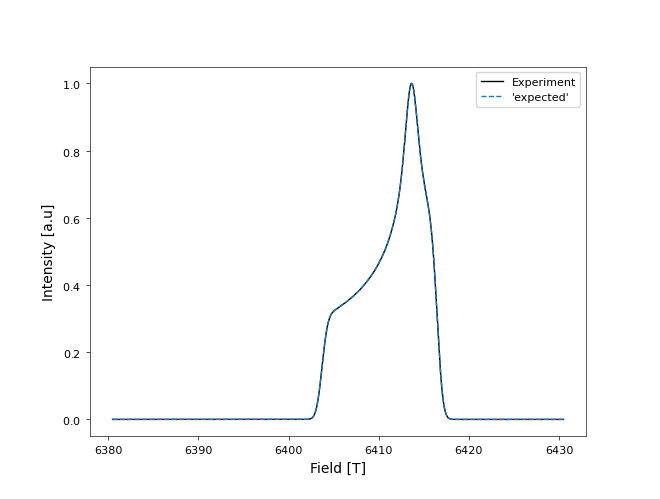

In [7]:
tme = TheoMatchExpe(['shifted-spectrum2.dat'],
                    experiment_file='spectrum2.dat',
                    
                     shifting_width=10)

sp = StandardPlotter(ax_pref={'xlabel': 'Field [T]',
                              'ylabel': 'Intensity [a.u]'}
                     )

sp.plot_data(tme.fieldexp, tme.intensexp, pstyle='-', color_plot='black', data_label='Experiment')
sp.plot_data(tme.fieldexp, tme.coeffs[0] * tme.intensities[0], pstyle='--', data_label="'expected'");
sp.axis_setter(legend=True)

We can see then, that the predicted shift is quite as expected

In [8]:
tme.shift

-8.000000000000007

And with this trick, we shifted the correlation

In [9]:
tme.corr, tme.error

(1.0, 5.414848257917464e-16)

## Fitting a function into another which does not correspond more than one specific part

Now let's take a function g(x) wich fits  to another f(x) only in a range a < x < b. If we have a whole spectrum, the fitting is quite bad

<Axes: xlabel='Field [T]', ylabel='Intensity [a.u]'>

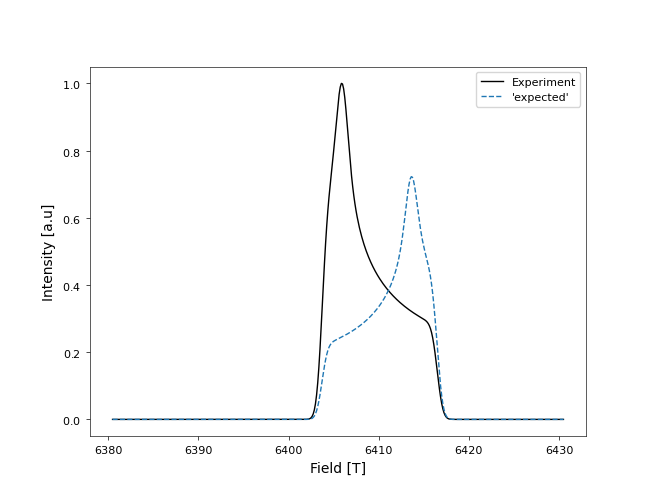

In [10]:
tme = TheoMatchExpe(['spectrum2.dat'],
                    experiment_file='spectrum1.dat',
                    
                     shifting_width=0)

sp = StandardPlotter(ax_pref={'xlabel': 'Field [T]',
                              'ylabel': 'Intensity [a.u]'})

sp.plot_data(tme.fieldexp, tme.intensexp, pstyle='-', color_plot='black', data_label='Experiment')
sp.plot_data(tme.fieldexp, tme.coeffs[0] * tme.intensities[0], pstyle='--', data_label="'expected'");
sp.axis_setter(legend=True)

In this case, tme.coeffs[0] is the expected c. and the correlation is:

In [11]:
tme.corr, tme.error

(0.6821669627127219, 3.577719112054213)

Even, using the translation trick, the fitting doesn't work so well

<Axes: xlabel='Field [T]', ylabel='Intensity [a.u]'>

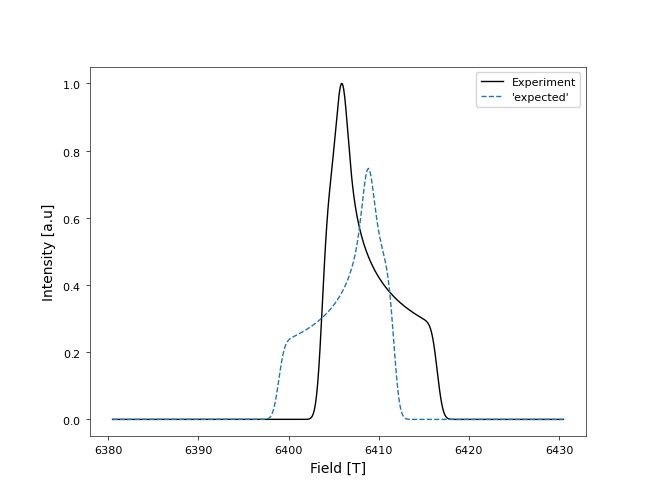

In [12]:
tme = TheoMatchExpe(['spectrum2.dat'],
                    experiment_file='spectrum1.dat',
                    
                     shifting_width=10)

sp = StandardPlotter(ax_pref={'xlabel': 'Field [T]',
                              'ylabel': 'Intensity [a.u]'})

sp.plot_data(tme.fieldexp, tme.intensexp, pstyle='-', color_plot='black', data_label='Experiment')
sp.plot_data(tme.fieldexp, tme.coeffs[0] * tme.intensities[0], pstyle='--', data_label="'expected'");
sp.axis_setter(legend=True)

the correlation improves, but not quite much:

In [13]:
tme.corr, tme.error

(0.71614135486836, 3.406189914303648)

<Axes: xlabel='Field [T]', ylabel='Intensity [a.u]'>

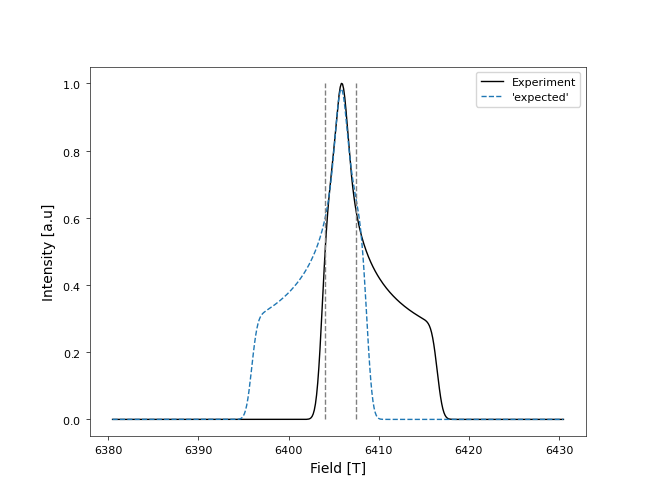

In [14]:
limi = [6404, 6407.5]

tme = TheoMatchExpe(['spectrum2.dat'],
                    experiment_file='spectrum1.dat',
                    fieldrange=limi,
                     shifting_width=10)

sp = StandardPlotter(ax_pref={'xlabel': 'Field [T]',
                              'ylabel': 'Intensity [a.u]'})

sp.plot_data(tme.fieldexp, tme.intensexp, pstyle='-', color_plot='black', data_label='Experiment')
sp.plot_data(tme.fieldexp, tme.coeffs[0] * tme.intensities[0], pstyle='--', data_label="'expected'");
sp.plot_data([limi[0], limi[0]], [0,1], pstyle='--', color_plot='gray');
sp.plot_data([limi[1], limi[1]], [0,1], pstyle='--', color_plot='gray');
sp.axis_setter(legend=True)

In [15]:
tme.corr, tme.error

(0.9936567996293036, 0.12915601536886243)

## Why error and correlation?

In certain applications, we need a quantity that says which function fits
better independent of the scale and the translation in the y axis. Let's see
what haappens with the error and the correlation, when we compare f(x) vs g(x)
with f(x) vs a * g(x) + b

In [16]:
tme = TheoMatchExpe(['shifted-spectrum2.dat'], experiment_file='spectrum2.dat')

In [17]:
error = np.linalg.norm(tme.intensexp - tme.intensfit)
corr = pearsonr(tme.intensexp, tme.intensfit)[0]

print(f'error of f(x) vs g(x): {error:0.5f}')
print(f'correlation of f(x) vs g(x): {corr:0.5f}')


error of f(x) vs g(x): 5.41808
correlation of f(x) vs g(x): 0.10279


In [18]:
error = np.linalg.norm(tme.intensexp - 7 * tme.intensfit + 4)
corr = pearsonr(tme.intensexp, 7 * tme.intensfit + 4)[0]

print(f'error of f(x) vs g(x): {error:0.5f}')
print(f'correlation of f(x) vs 7*g(x)+4: {corr:0.5f}')

error of f(x) vs g(x): 77.76395
correlation of f(x) vs 7*g(x)+4: 0.10279


Notice that the correlation does not depend on the scale and translation on the
y axis.